In [1]:
"""
plots_heur_random.ipynb

Plots the "plausible sequences" curve as a function of the number of
heuristic split iterations (random-token variant) for three models
(L1B, G1B, M8B) at top-p=0.95, T=1.3, num_seq=4.

Pickle inputs are read from ``<work>/outputs/heuristic_new/<short>/`` and
the figure is saved under ``<work>/figures/heur/``.
"""

%matplotlib inline

import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from transformers import AutoTokenizer

# Resolve project paths from the notebook's location: <work>/notebooks/...
WORK_DIR = os.path.abspath(os.path.join(os.getcwd(), ".."))
CPT_DIR = os.path.join(WORK_DIR, "outputs", "cpt")
HEUR_DIR = os.path.join(WORK_DIR, "outputs", "heuristic_new")
FIGURES_DIR = os.path.join(WORK_DIR, "figures")

sys.path.insert(0, os.path.join(WORK_DIR, "src"))
import utils  # noqa: E402

# Short name -> (filename stem used in outputs/, HuggingFace model id).
MODEL_INFO = {
    "L1B": ("Llama-3.2-1B-Instruct",        "meta-llama/Llama-3.2-1B-Instruct"),
    "L3B": ("Llama-3.2-3B-Instruct",        "meta-llama/Llama-3.2-3B-Instruct"),
    "G1B": ("Gemma-3-1b-it",                "google/gemma-3-1b-it"),
    "G4B": ("Gemma-3-4b-it",                "google/gemma-3-4b-it"),
    "M8B": ("Ministral-8B-Instruct-2410",   "mistralai/Ministral-8B-Instruct-2410"),
}

# Half-width multiplier for the standard-deviation bands drawn around the mean.
t_val = 2.3


In [20]:
# Sanity check: load one factual_model file for L1B at T=1.0, top-p=1.0,
# and print summary CPT statistics.

short = "L1B"
temperature = 1.0
top_p = 1.0
model_str, hf_id = MODEL_INFO[short]

tokenizer = AutoTokenizer.from_pretrained(hf_id)
sanity_path = os.path.join(
    CPT_DIR,
    f"factual_model{model_str}_p{top_p}_kNone_numprompts400_maxoutlen200_temp{temperature}.pkl",
)
with open(sanity_path, "rb") as f:
    data = pickle.load(f)

char = [0] * len(data[0]["output"])
tok = [0] * len(data[0]["output"])
for num_seq in range(len(data[0]["output"])):
    for prompt_id in range(len(data)):
        char[num_seq] += len(tokenizer.decode(data[prompt_id]["output"][0]))
        tok[num_seq]  += len(data[prompt_id]["output"][0])

cpts = np.vstack(char) / np.stack(tok)
print(short)
print("Mean CPT      :", np.mean(cpts))
print("Mean 100*cpt-1:", np.mean(100 * cpts - 1, axis=0))
print("CPT std       :", np.std(cpts))


L1
Mean CPT 4.392827152226368
Mean overchard [438.28271522]
Mean std 0.0


In [6]:
# Load the random-variant heuristic results for three models at T=1.3,
# num_seq=4, p=0.95. The original ``data_09`` / ``data_095`` / ``data_099``
# variable names are kept for compatibility with the plotting cell below;
# they index by *model*, not by top-p.

def load_heur(short_name, T=1.3, num_seq=4, p=0.95, variant="random"):
    """Load a heuristic-misreporting pickle from
    ``HEUR_DIR/<short_name>/heuristic_model_<variant>_<MS>_T_<T>_numseq_<N>_p_<P>.pkl``.
    """
    model_str = MODEL_INFO[short_name][0]
    path = os.path.join(
        HEUR_DIR, short_name,
        f"heuristic_model_{variant}_{model_str}_T_{T}_numseq_{num_seq}_p_{p}.pkl",
    )
    with open(path, "rb") as f:
        return pickle.load(f)


data_09  = load_heur("L1B")
data_095 = load_heur("G1B")
data_099 = load_heur("M8B")

print(data_09["top_p_count"][0])
print(data_095["top_p_count"][0])
print(data_099["top_p_count"][0])


[212, 160, 160, 120, 142, 113, 108, 85, 83, 64, 76, 61, 57, 59, 62, 49, 42, 47, 40, 27, 26, 38, 20, 18, 10, 8, 4, 4, 0, 0, 0, 0]
[335, 301, 261, 262, 191, 166, 181, 141, 155, 135, 117, 117, 101, 107, 89, 74, 84, 57, 67, 83, 47, 43, 41, 29, 15, 17, 17, 7, 6, 5, 2, 4]
[143, 115, 114, 109, 104, 109, 105, 107, 93, 98, 74, 74, 95, 83, 70, 78, 83, 70, 75, 74, 69, 74, 64, 42, 55, 39, 40, 32, 15, 16, 5, 5]


/tmp/ipykernel_3239741/2374656120.py:89: UserWarning: The palette list has more values (8) than needed (3), which may not be intended.
  sns.lineplot(data=df, x="splits", y='mean_percent', hue='top-p', palette=palette, ax=ax, linewidth=0.5, markersize=4,marker="o", err_style= "band", linestyle="-", markeredgewidth=0)


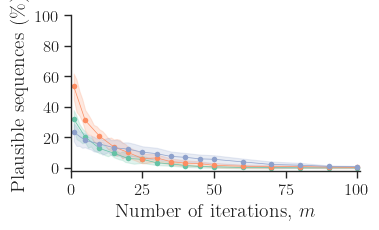

In [19]:
# Plot: percentage of plausible sequences vs number of heuristic
# iterations m, for the three models. The mean is taken across the four
# num_seq replicates; std bands are smoothed and scaled by ``t_val``.

num_prompts = len(data_09["generated_outputs"][0])

# Split depths at which the heuristic-misreporting result was recorded.
splits = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
          19, 20, 22, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]
# Subset of split depths to actually mark with points in the lineplot.
indices = [splits.index(element) for element in
           [1, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100]]


percentage_09  = []
percentage_095 = []
percentage_099 = []

for seq_idx in range(len(data_099["top_p_count"])):
    percentage_09.append(np.array(
        [data_09["top_p_count"][seq_idx][i] / num_prompts * 100 for i in range(len(splits))]))
    percentage_095.append(np.array(
        [data_095["top_p_count"][seq_idx][i] / num_prompts * 100 for i in range(len(splits))]))
    percentage_099.append(np.array(
        [data_099["top_p_count"][seq_idx][i] / num_prompts * 100 for i in range(len(splits))]))


def smooth_window2(arr, k=5):
    """Symmetric moving-average smoother with window ``k`` (odd, >=1).
    Edges are returned unchanged."""
    if k < 1 or k % 2 == 0:
        raise ValueError("Window size k must be an odd integer >= 1.")
    arr = np.asarray(arr, dtype=float)
    smoothed = np.copy(arr)
    half = k // 2
    for i in range(half, len(arr) - half):
        smoothed[i] = np.mean(arr[i - half: i + half + 1])
    return smoothed


mean_09  = np.mean(np.stack(percentage_09[:4],  axis=0), axis=0)
std_09   = np.std(np.stack(percentage_09[:4],  axis=0), axis=0)
mean_095 = np.mean(np.stack(percentage_095[:4], axis=0), axis=0)
std_095  = np.std(np.stack(percentage_095[:4], axis=0), axis=0)
mean_099 = np.mean(np.stack(percentage_099[:4], axis=0), axis=0)
std_099  = np.std(np.stack(percentage_099[:4], axis=0), axis=0)

std_09  = smooth_window2(std_09)
std_095 = smooth_window2(std_095)
std_099 = smooth_window2(std_099)

splits_new = np.array(splits)[indices]
mean_09_new  = np.array(mean_09)[indices]
mean_095_new = np.array(mean_095)[indices]
mean_099_new = np.array(mean_099)[indices]
std_09_new   = np.array(std_09)[indices]
std_095_new  = np.array(std_095)[indices]
std_099_new  = np.array(std_099)[indices]

# Reported success rate is 0.8 of the raw plausibility count.
mean_09  = mean_09  * 0.8
mean_095 = mean_095 * 0.8
mean_099 = mean_099 * 0.8
mean_09_new  = mean_09_new  * 0.8
mean_095_new = mean_095_new * 0.8
mean_099_new = mean_099_new * 0.8

df = pd.DataFrame({
    "mean_percent": np.concatenate((mean_09_new, mean_095_new, mean_099_new)),
    "top-p": ["085"] * len(mean_09_new) + ["09"] * len(mean_095_new) + ["095"] * len(mean_099_new),
    "splits": np.concatenate((splits_new, splits_new, splits_new)),
})

sns.set_theme(context="paper", style="ticks", font_scale=1)
palette = sns.color_palette("Set2")
utils.latexify()  # Computer Modern, with TeX

fig_width, fig_height = utils.get_fig_dim(469, fraction=0.6)
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

sns.lineplot(data=df, x="splits", y="mean_percent", hue="top-p", palette=palette,
             ax=ax, linewidth=0.5, markersize=4, marker="o",
             err_style="band", linestyle="-", markeredgewidth=0)

ax.fill_between(splits, mean_09  - std_09  * t_val, mean_09  + std_09  * t_val, color=palette[0], alpha=0.2)
ax.fill_between(splits, mean_095 - std_095 * t_val, mean_095 + std_095 * t_val, color=palette[1], alpha=0.2)
ax.fill_between(splits, mean_099 - std_099 * t_val, mean_099 + std_099 * t_val, color=palette[2], alpha=0.2)

# Custom legend (the auto legend tracks the hue order in df).
legend_elements = [
    Patch(facecolor=palette[2], edgecolor="white", label=r"$p=0.95$"),
    Patch(facecolor=palette[1], edgecolor="white", label=r"$p=0.90$"),
    Patch(facecolor=palette[0], edgecolor="white", label=r"$p=0.85$"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize="7.5", frameon=True)

sns.despine(ax=ax)
ax.set_xlabel(r"Number of iterations, $m$", fontsize=14)
ax.set_ylabel(r"Plausible sequences (\%)", fontsize=14)

plt.legend().set_visible(False)
ax.set_ylim(-2, 100)
ax.set_yticks([0, 20, 40, 60, 80, 100])
ax.tick_params(axis="y", which="major", labelsize=12)
ax.tick_params(axis="x", which="major", labelsize=12)
ax.set_xlim(0, 101)

fig.tight_layout()
plt.show()
out_path = os.path.join(FIGURES_DIR, "heur", "random_plausibility.pdf")
os.makedirs(os.path.dirname(out_path), exist_ok=True)
fig.savefig(out_path, dpi=300)
